# TKAN vs. LSTM for Limit Order Book Classification

This notebook compares a **Temporal Kolmogorov-Arnold Network (TKAN)** against a standard **LSTM** for predicting Order Flow Imbalance (OFI) direction from high-frequency Limit Order Book (LOB) data.

**Pipeline overview:**
1. Load raw LOBSTER tick data and assign column names.
2. Resample to fixed intervals and compute microstructural features.
3. Engineer stationary features (distance-to-mid, volume imbalance, etc.).
4. Tune hyperparameters with Optuna on a small date window.
5. Train both models using Day-Forward Validation.
6. Evaluate on a clean holdout set and compare with a Logistic Regression baseline.
7. Run a Wilcoxon signed-rank test for statistical significance.

## 1. Setup and Imports

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')

# Ensure the project root is on the Python path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Select the best available compute device (CUDA > MPS > CPU)
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

Using device: mps


## 2. Load LOB Data

We use LOBSTER-format tick data for **AAPL** over the period 2025-09-22 to 2025-10-20.  
Each file contains one trading day (09:30-16:00 ET). The loader skips weekends/holidays automatically.

In [2]:
from src.data_loader import load_lob_data_range

# Load tick-level order book snapshots for AAPL across the full date range
df = load_lob_data_range('AAPL', '2025-09-22', '2025-10-20')
print(f"Loaded {len(df):,} ticks")
df.head()

Loaded 19,229,302 ticks


,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2
Time,,,,,,,,
2025-09-22 09:30:00.012279879,2484600,100,2483000,100,2485200,1100,2482800,12
2025-09-22 09:30:00.012289710,2484600,100,2482800,12,2485200,1100,2482500,98
2025-09-22 09:30:00.012988161,2484600,100,2483000,100,2485200,1100,2482800,12
2025-09-22 09:30:00.013004265,2484600,100,2483000,200,2485200,1100,2482800,12
2025-09-22 09:30:00.013042996,2484200,100,2483000,200,2484600,100,2482800,12


## 3. Feature Engineering

### 3.1 Basic Features

We resample the tick stream into fixed time bars and compute:
- **OFI** (Order Flow Imbalance) — net buying/selling pressure per bar (Cont et al.).
- **Mid-price** — average of best ask and best bid.
- **Spread** — distance between best ask and best bid.

In [3]:
from src.features import generate_features

# Resample ticks into 10-second bars with OFI, mid-price, and spread
df_resampled = generate_features(df, resample_freq='10s')

print("Shape after resampling:", df_resampled.shape)
df_resampled[['ofi', 'mid_price', 'spread']].head(20)

Shape after resampling: (47486, 11)


,ofi,mid_price,spread
Time,,,
2025-09-22 09:30:00,66286.0,2492550.0,700.0
2025-09-22 09:30:10,-10713.0,2487750.0,700.0
2025-09-22 09:30:20,24411.0,2492250.0,500.0
2025-09-22 09:30:30,7843.0,2493150.0,500.0
2025-09-22 09:30:40,-2414.0,2493950.0,700.0
2025-09-22 09:30:50,6682.0,2494850.0,300.0
2025-09-22 09:31:00,6659.0,2494600.0,400.0
2025-09-22 09:31:10,12814.0,2496850.0,500.0
2025-09-22 09:31:20,40816.0,2498750.0,300.0


### 3.2 Advanced Stationary Features

Raw prices are non-stationary and would leak future information into the model.  
We replace them with **relative** features:
- Distance from each level to mid-price.
- Volume imbalance ratios at levels 1 and 2.
- Micro-price pressure (size-weighted mid deviation).
- Rolling OFI momentum and volatility (60-bar windows).

After this step the absolute prices are dropped.

In [4]:
from src.features import engineer_lob_features

# Replace raw prices with stationary derived features
df_resampled = engineer_lob_features(df_resampled)

print("Final shape for modeling:", df_resampled.shape)
df_resampled.head()

Final shape for modeling: (47426, 15)


,ofi,ask_size_1,bid_size_1,ask_size_2,bid_size_2,spread,ask_dist_1,bid_dist_1,ask_dist_2,bid_dist_2,vol_imb_1,vol_imb_2,price_pressure,ofi_momentum,volatility
Time,,,,,,,,,,,,,,,
2025-09-22 09:40:00,-2719.0,247.274740,305.237370,298.993080,344.235986,300.0,150.0,150.0,250.0,250.0,0.104907,0.070337,15.736070,10861.216667,0.000807
2025-09-22 09:40:10,-2659.0,238.089861,280.396925,283.279193,370.851033,200.0,100.0,100.0,200.0,200.0,0.081597,0.133875,8.159671,10995.450000,0.000764
2025-09-22 09:40:20,-4450.0,221.589812,226.080812,299.455381,266.930678,400.0,200.0,200.0,400.0,300.0,0.010032,-0.057425,2.006330,10514.433333,0.000735
2025-09-22 09:40:30,-13059.0,233.006052,644.119704,278.503699,502.924681,200.0,100.0,100.0,200.0,300.0,0.468705,0.287193,46.870520,10166.066667,0.000737
2025-09-22 09:40:40,-3078.0,221.680147,211.823529,302.522059,229.711397,300.0,150.0,150.0,250.0,250.0,-0.022737,-0.136802,-3.410623,10155.000000,0.000736


## 4. Exploratory Data Analysis

Quick visual sanity checks before modeling:
- **Intraday profile** — how OFI, spread, and volatility evolve throughout one trading day.
- **Daily distributions** — violin plots showing whether the feature distributions are stable across days.

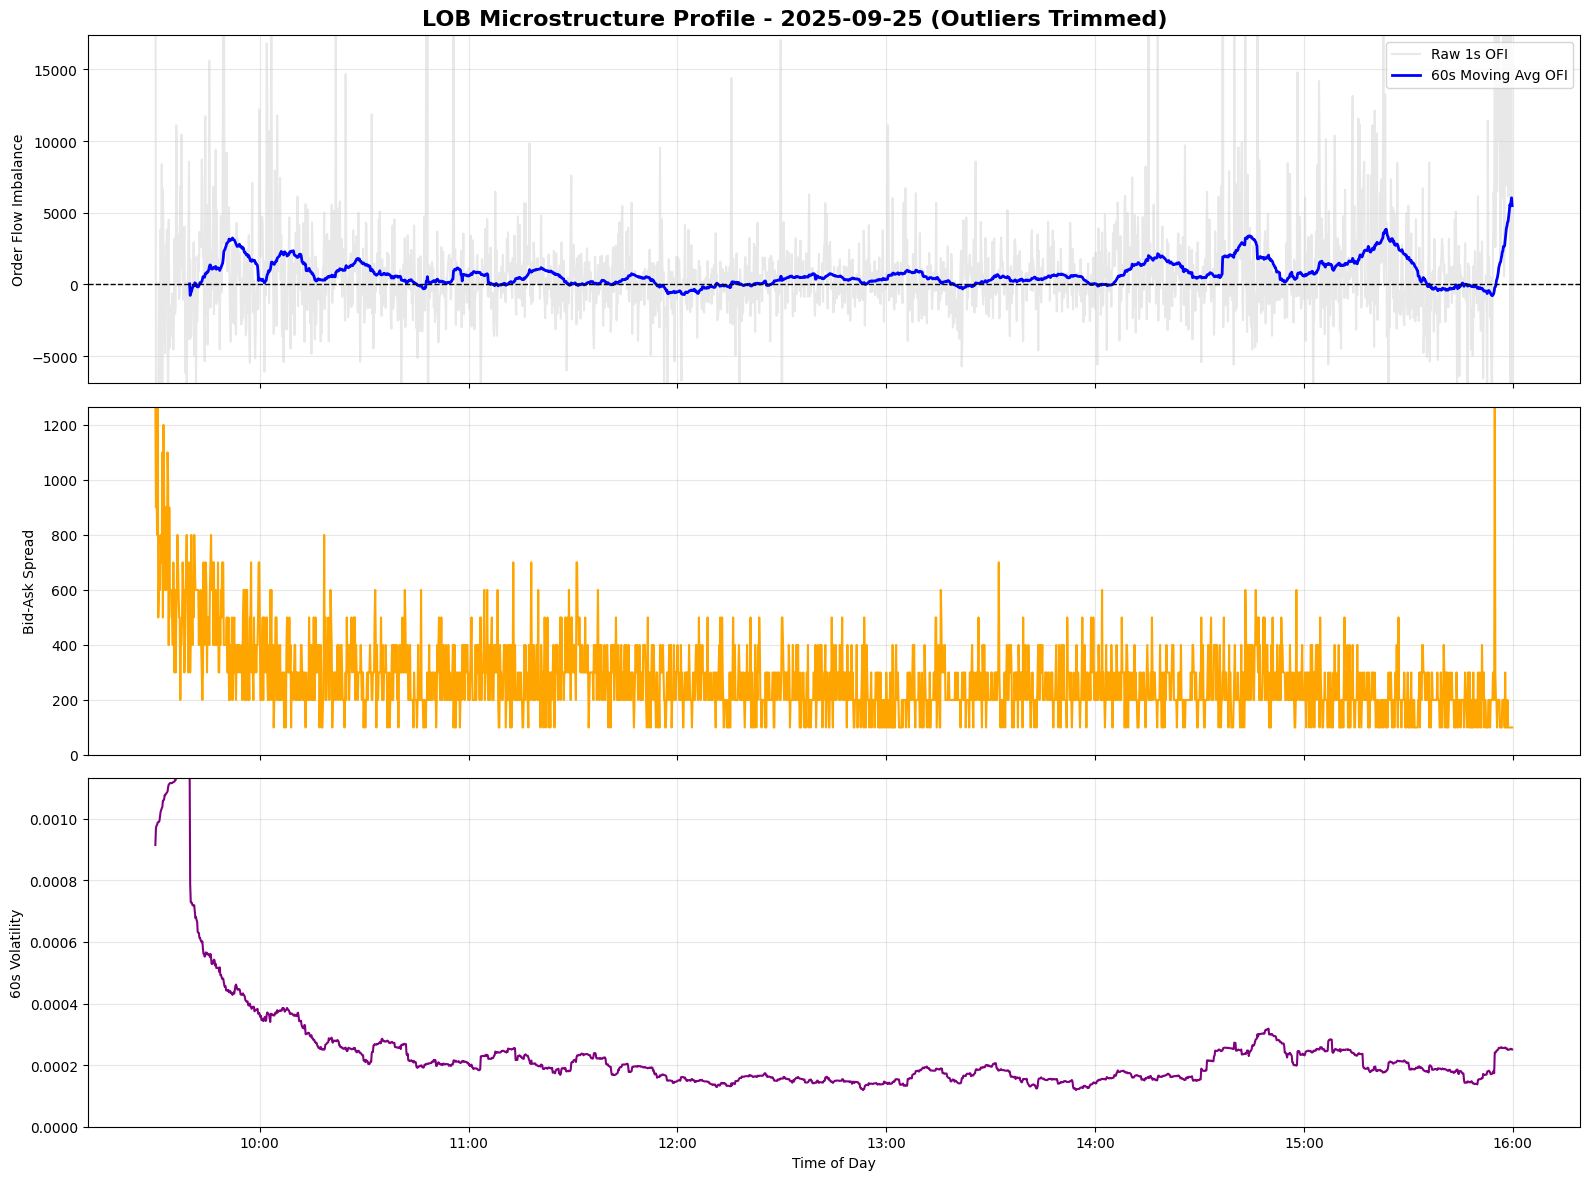

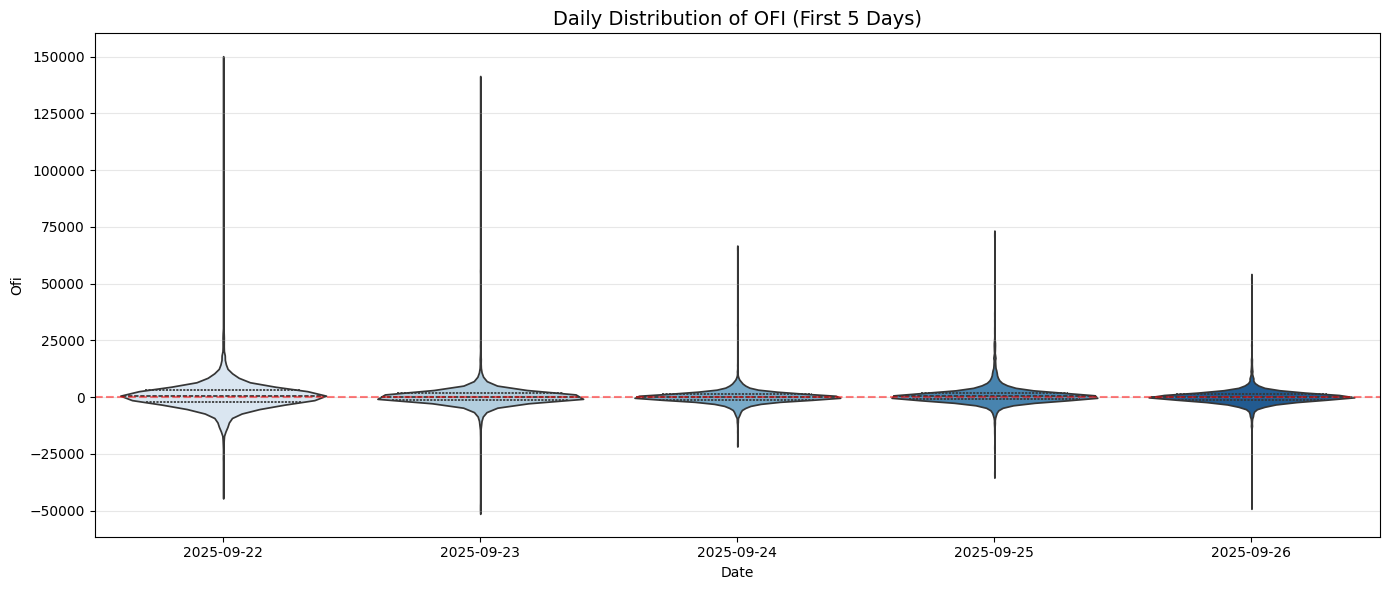

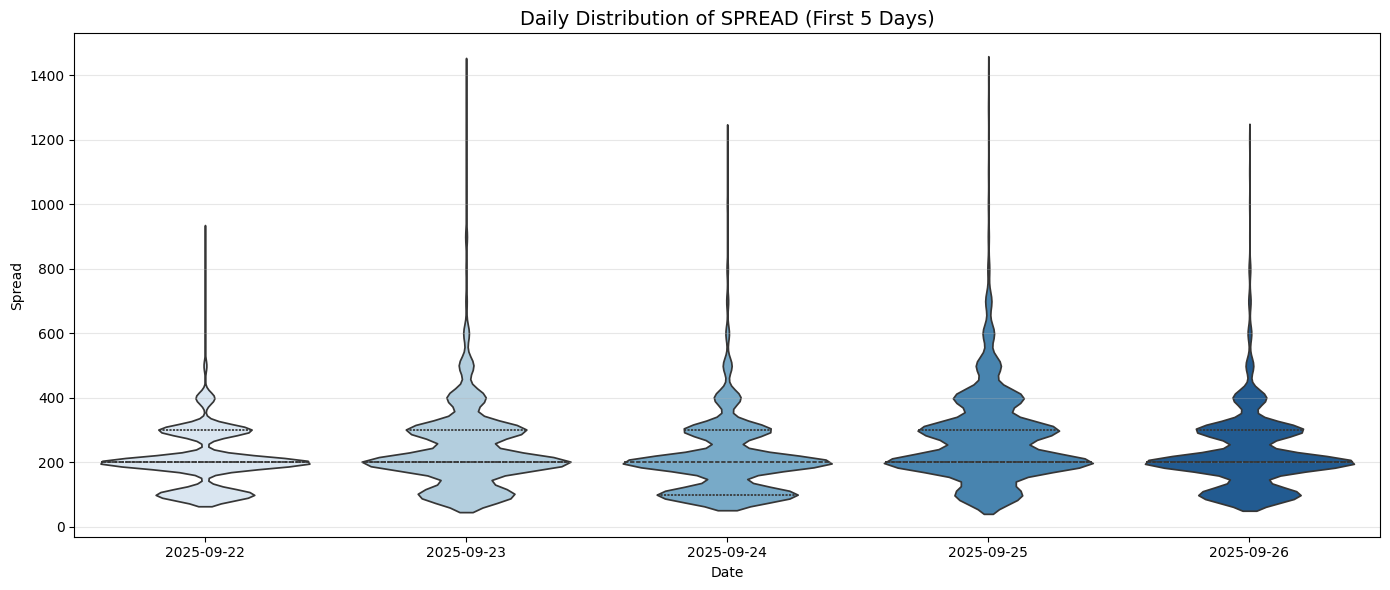

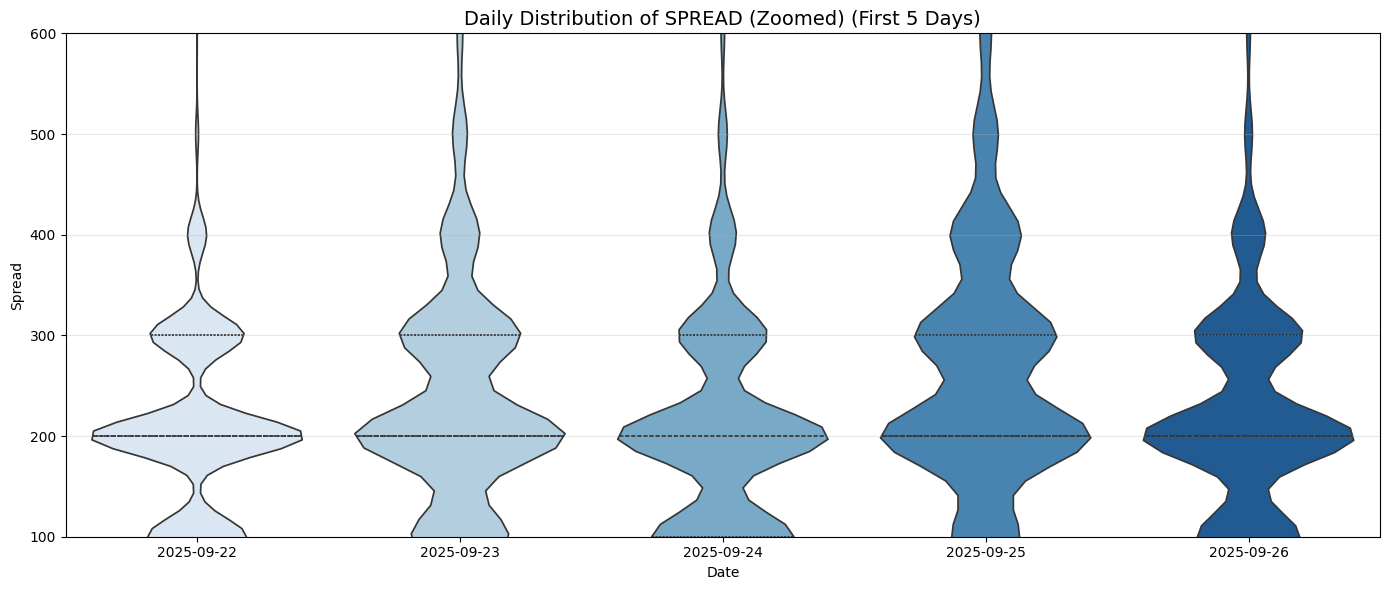

In [5]:
from src.visualizations import plot_single_day_profile, plot_daily_distributions

# Intraday microstructure profile for a single day (outliers trimmed)
plot_single_day_profile(df_resampled, '2025-09-25', trim_outliers=True)

# Daily OFI distributions across the first 5 trading days
plot_daily_distributions(df_resampled, feature='ofi', days_to_plot=5)

# Daily spread distributions (full range, then zoomed)
plot_daily_distributions(df_resampled, feature='spread', days_to_plot=5)
plot_daily_distributions(df_resampled, feature='spread', days_to_plot=5, trim_outliers=True)

## 5. Modeling Setup

### 5.1 Target Variable and Train/Test Split

The target is the **next-bar OFI** discretised into three classes via training-set quantiles:
- Class 0 — Strong Sell (below 20th percentile)
- Class 1 — Neutral (between 20th and 80th percentile)
- Class 2 — Strong Buy (above 80th percentile)

We reserve the **last 5 trading days** as a clean holdout set that is never seen during training or tuning.

In [6]:
from src.models.tkan_class import TKANClassifier
from src.models.lstm import LSTMClassifier
from src.train import run_day_forward_validation

# The 15 input features the models will see
feature_cols = [
    'ask_size_1', 'bid_size_1', 'ask_size_2', 'bid_size_2',
    'ofi', 'spread', 'ask_dist_1', 'bid_dist_1', 'ask_dist_2', 'bid_dist_2',
    'vol_imb_1', 'vol_imb_2', 'price_pressure', 'ofi_momentum', 'volatility'
]

# Create the target: next bar's OFI value
df_full = df_resampled.copy()
df_full['next_ofi'] = df_full['ofi'].shift(-1)
df_full.dropna(subset=['next_ofi'], inplace=True)

# Split dates into history (train+val) and holdout (test)
df_full['date_only'] = df_full.index.date
unique_dates = sorted(df_full['date_only'].unique())

num_test_days = 5
holdout_dates = unique_dates[-num_test_days:]
history_dates = unique_dates[:-num_test_days]
hyper_dates = unique_dates[:3]  # small window for fast Optuna tuning

df_train_val = df_full[df_full['date_only'].isin(history_dates)].copy()
df_test_clean = df_full[df_full['date_only'].isin(holdout_dates)].copy()
hyper_df = df_full[df_full['date_only'].isin(hyper_dates)].copy()

print(f"Training/Validation period : {history_dates[0]} to {history_dates[-1]}")
print(f"Holdout test period        : {holdout_dates[0]} to {holdout_dates[-1]}")
print(f"Optuna tuning window       : {hyper_dates[0]} to {hyper_dates[-1]}")

Training/Validation period : 2025-09-22 to 2025-10-13
Holdout test period        : 2025-10-14 to 2025-10-20
Optuna tuning window       : 2025-09-22 to 2025-09-24


## 6. Hyperparameter Tuning with Optuna

We run a short Optuna study (20 trials) on only the first 3 trading days to find good hyperparameters for each model. The objective is the mean Macro-F1 across walk-forward folds.

In [7]:
import optuna

def tkan_objective(trial):
    # Search space for TKAN architecture
    hidden_size = trial.suggest_int('hidden_size', 5, 10)
    seq_length = trial.suggest_int('seq_length', 5, 10)
    grid_size = trial.suggest_int('grid_size', 3, 5)
    spline_order = trial.suggest_int('spline_order', 2, 3)
    num_layers = trial.suggest_int('num_layers', 1, 2)

    tkan_kwargs = {
        'input_size': 15, 'hidden_size': hidden_size, 'num_classes': 3,
        'num_layers': num_layers, 'grid_size': grid_size, 'spline_order': spline_order
    }
    try:
        _, f1_scores, _, _ = run_day_forward_validation(
            df=hyper_df, feature_cols=feature_cols,
            model_class=TKANClassifier, model_kwargs=tkan_kwargs,
            device=device, train_window_days=2, seq_length=seq_length, num_epochs=30
        )
        return np.mean(f1_scores)
    except Exception:
        raise optuna.exceptions.TrialPruned()

print("Starting Optuna search for TKAN...")
study_tkan = optuna.create_study(direction='maximize')
study_tkan.optimize(tkan_objective, n_trials=20, n_jobs=-1)

best_params = study_tkan.best_params
print(f"\nBest TKAN params: {best_params}")
print(f"Best TKAN Macro-F1: {study_tkan.best_value:.4f}")

[I 2026-04-09 13:58:11,201] A new study created in memory with name: no-name-4c90a1d1-9894-41e2-814f-28f1d185e2ff


Starting Optuna search for TKAN...
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Tr

[I 2026-04-09 13:58:22,102] Trial 2 finished with value: 0.28596983454652086 and parameters: {'hidden_size': 10, 'seq_length': 9, 'grid_size': 3, 'spline_order': 3, 'num_layers': 2}. Best is trial 2 with value: 0.28596983454652086.


Fold 1 | Best F1: 0.2860 | Best Acc: 0.3642

🏆 TKANClassifier RESULTS 🏆
Macro-F1: 0.2860 (+/- 0.0000)
Accuracy: 0.3642 (+/- 0.0000)
Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---


[I 2026-04-09 13:58:27,306] Trial 11 finished with value: 0.2296734143336255 and parameters: {'hidden_size': 10, 'seq_length': 7, 'grid_size': 5, 'spline_order': 3, 'num_layers': 2}. Best is trial 2 with value: 0.28596983454652086.


...

Fold 1 | Best F1: 0.3264 | Best Acc: 0.4717

🏆 TKANClassifier RESULTS 🏆
Macro-F1: 0.3264 (+/- 0.0000)
Accuracy: 0.4717 (+/- 0.0000)


[I 2026-04-09 13:59:46,909] Trial 10 finished with value: 0.2903954522233454 and parameters: {'hidden_size': 6, 'seq_length': 8, 'grid_size': 5, 'spline_order': 2, 'num_layers': 2}. Best is trial 12 with value: 0.39059971755326656.
[I 2026-04-09 13:59:46,909] Trial 8 finished with value: 0.3758159084181569 and parameters: {'hidden_size': 6, 'seq_length': 8, 'grid_size': 5, 'spline_order': 2, 'num_layers': 2}. Best is trial 12 with value: 0.39059971755326656.


Fold 1 | Best F1: 0.3758 | Best Acc: 0.5763

🏆 TKANClassifier RESULTS 🏆
Macro-F1: 0.3758 (+/- 0.0000)
Accuracy: 0.5763 (+/- 0.0000)
Fold 1 | Best F1: 0.2904 | Best Acc: 0.3589

🏆 TKANClassifier RESULTS 🏆
Macro-F1: 0.2904 (+/- 0.0000)
Accuracy: 0.3589 (+/- 0.0000)


[I 2026-04-09 13:59:47,428] Trial 9 finished with value: 0.3673330003528599 and parameters: {'hidden_size': 6, 'seq_length': 6, 'grid_size': 3, 'spline_order': 3, 'num_layers': 2}. Best is trial 12 with value: 0.39059971755326656.


Fold 1 | Best F1: 0.3673 | Best Acc: 0.6028

🏆 TKANClassifier RESULTS 🏆
Macro-F1: 0.3673 (+/- 0.0000)
Accuracy: 0.6028 (+/- 0.0000)

Best TKAN params: {'hidden_size': 6, 'seq_length': 9, 'grid_size': 3, 'spline_order': 3, 'num_layers': 2}
Best TKAN Macro-F1: 0.3906


In [8]:
def lstm_objective(trial):
    # Search space for LSTM architecture
    hidden_size = trial.suggest_int('hidden_size', 5, 10)
    seq_length = trial.suggest_int('seq_length', 5, 10)
    num_layers = trial.suggest_int('num_layers', 1, 2)

    lstm_kwargs = {
        'input_size': 15, 'hidden_size': hidden_size,
        'num_classes': 3, 'num_layers': num_layers
    }
    try:
        _, f1_scores, _, _ = run_day_forward_validation(
            df=hyper_df, feature_cols=feature_cols,
            model_class=LSTMClassifier, model_kwargs=lstm_kwargs,
            device=device, train_window_days=2, seq_length=seq_length, num_epochs=30
        )
        return np.mean(f1_scores)
    except Exception:
        raise optuna.exceptions.TrialPruned()

print("Starting Optuna search for LSTM...")
study_lstm = optuna.create_study(direction='maximize')
study_lstm.optimize(lstm_objective, n_trials=20, n_jobs=-1)

lstm_best_params = study_lstm.best_params
print(f"\nBest LSTM params: {lstm_best_params}")
print(f"Best LSTM Macro-F1: {study_lstm.best_value:.4f}")

[I 2026-04-09 13:59:47,434] A new study created in memory with name: no-name-b850eb0a-8c83-4438-9c5c-2c595dcd7d92


Starting Optuna search for LSTM...
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Tr

[I 2026-04-09 13:59:55,248] Trial 10 finished with value: 0.33586838839156036 and parameters: {'hidden_size': 9, 'seq_length': 5, 'num_layers': 1}. Best is trial 10 with value: 0.33586838839156036.


Fold 1 | Best F1: 0.3359 | Best Acc: 0.7263

🏆 LSTMClassifier RESULTS 🏆
Macro-F1: 0.3359 (+/- 0.0000)
Accuracy: 0.7263 (+/- 0.0000)
Starting Day-Forward Validation (LSTMClassifier)

--- FOLD 1 | Train: 2 days | Test: 2025-09-24 ---


[I 2026-04-09 13:59:56,031] Trial 4 finished with value: 0.2932884831010732 and parameters: {'hidden_size': 9, 'seq_length': 9, 'num_layers': 2}. Best is trial 10 with value: 0.33586838839156036.
[I 2026-04-09 13:59:56,145] Trial 3 finished with value: 0.2932757655712801 and parameters: {'hidden_size': 7, 'seq_length': 5, 'num_layers': 2}. Best is trial 10 with value: 0.33586838839156036.


...

Fold 1 | Best F1: 0.3498 | Best Acc: 0.5846

🏆 LSTMClassifier RESULTS 🏆
Macro-F1: 0.3498 (+/- 0.0000)
Accuracy: 0.5846 (+/- 0.0000)


[I 2026-04-09 14:00:59,887] Trial 14 finished with value: 0.35940616827700916 and parameters: {'hidden_size': 8, 'seq_length': 9, 'num_layers': 2}. Best is trial 12 with value: 0.3901936110626436.


Fold 1 | Best F1: 0.3594 | Best Acc: 0.5028

🏆 LSTMClassifier RESULTS 🏆
Macro-F1: 0.3594 (+/- 0.0000)
Accuracy: 0.5028 (+/- 0.0000)


[I 2026-04-09 14:01:00,117] Trial 17 finished with value: 0.12717439723101076 and parameters: {'hidden_size': 7, 'seq_length': 9, 'num_layers': 2}. Best is trial 12 with value: 0.3901936110626436.


Fold 1 | Best F1: 0.1272 | Best Acc: 0.1210

🏆 LSTMClassifier RESULTS 🏆
Macro-F1: 0.1272 (+/- 0.0000)
Accuracy: 0.1210 (+/- 0.0000)

Best LSTM params: {'hidden_size': 10, 'seq_length': 9, 'num_layers': 1}
Best LSTM Macro-F1: 0.3902


## 7. Training with Day-Forward Validation

Day-Forward Validation is an expanding-window walk-forward scheme:
- **Fold k**: train on days 1..k, test on day k+1.
- The model is re-initialised each fold (no warm-starting).
- Quantile thresholds for class labels are computed on training data only.

We train both TKAN and LSTM on the full history period and save the best weights.

In [9]:
os.makedirs("saved_models", exist_ok=True)

# --- TKAN ---
tkan_kwargs = {
    'input_size': 15,
    'hidden_size': best_params['hidden_size'],
    'num_classes': 3,
    'num_layers': best_params['num_layers'],
    'grid_size': best_params['grid_size'],
    'spline_order': best_params['spline_order']
}

trained_tkan, tkan_f1_scores, tkan_acc_scores, tkan_history_dict = run_day_forward_validation(
    df=df_train_val, feature_cols=feature_cols,
    model_class=TKANClassifier, model_kwargs=tkan_kwargs,
    device=device, train_window_days=1, seq_length=best_params['seq_length']
)
torch.save(trained_tkan.state_dict(), "saved_models/best_tkan.pth")

# --- LSTM ---
lstm_kwargs = {
    'input_size': 15,
    'hidden_size': lstm_best_params['hidden_size'],
    'num_layers': lstm_best_params['num_layers'],
    'num_classes': 3
}

trained_lstm, lstm_f1_scores, lstm_acc_scores, lstm_history_dict = run_day_forward_validation(
    df=df_train_val, feature_cols=feature_cols,
    model_class=LSTMClassifier, model_kwargs=lstm_kwargs,
    device=device, train_window_days=1, seq_length=lstm_best_params['seq_length']
)
torch.save(trained_lstm.state_dict(), "saved_models/best_lstm.pth")

Starting Day-Forward Validation (TKANClassifier)

--- FOLD 1 | Train: 1 days | Test: 2025-09-23 ---
Fold 1 | Best F1: 0.3158 | Best Acc: 0.4269

--- FOLD 2 | Train: 2 days | Test: 2025-09-24 ---
Fold 2 | Best F1: 0.4273 | Best Acc: 0.6491

--- FOLD 3 | Train: 3 days | Test: 2025-09-25 ---
Fold 3 | Best F1: 0.3716 | Best Acc: 0.4517

--- FOLD 4 | Train: 4 days | Test: 2025-09-26 ---
Fold 4 | Best F1: 0.4449 | Best Acc: 0.5873

--- FOLD 5 | Train: 5 days | Test: 2025-09-29 ---
Fold 5 | Best F1: 0.4115 | Best Acc: 0.5804

--- FOLD 6 | Train: 6 days | Test: 2025-09-30 ---
Fold 6 | Best F1: 0.4141 | Best Acc: 0.5521

--- FOLD 7 | Train: 7 days | Test: 2025-10-01 ---
Fold 7 | Best F1: 0.3864 | Best Acc: 0.4247

--- FOLD 8 | Train: 8 days | Test: 2025-10-02 ---
Fold 8 | Best F1: 0.4372 | Best Acc: 0.5774

--- FOLD 9 | Train: 9 days | Test: 2025-10-03 ---
Fold 9 | Best F1: 0.4148 | Best Acc: 0.4966

--- FOLD 10 | Train: 10 days | Test: 2025-10-06 ---
Fold 10 | Best F1: 0.4293 | Best Acc: 0.563

## 8. Holdout Test Evaluation

We now evaluate both trained models on the **5 holdout days** that were never used during training or tuning.

Steps:
1. Compute class thresholds from the training set only (no leakage).
2. Scale the holdout features using the training-set scaler.
3. Build a DataLoader with day-aware sequence windows.
4. Run inference and plot confusion matrices.

In [10]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from src.train import LOBSequenceDataset, assign_classes

# Compute class thresholds strictly from training data
q_lower = df_train_val['next_ofi'].quantile(0.2)
q_upper = df_train_val['next_ofi'].quantile(0.8)

# Apply class labels to the holdout set
df_test_clean = assign_classes(df_test_clean, q_lower, q_upper)

# Extract arrays
X_train_val = df_train_val[feature_cols].values
X_test_clean = df_test_clean[feature_cols].values
y_test_clean = df_test_clean['target'].values
dates_test_clean = df_test_clean['date_only'].values

# Fit scaler on training data, transform holdout data
scaler = StandardScaler()
scaler.fit(X_train_val)
X_test_clean_scaled = scaler.transform(X_test_clean)

# Build the test DataLoader with day-boundary-aware windowing
seq_length = best_params['seq_length']
clean_test_dataset = LOBSequenceDataset(
    X=X_test_clean_scaled, y=y_test_clean,
    dates=dates_test_clean, sequence_length=seq_length
)
clean_test_loader = DataLoader(clean_test_dataset, batch_size=1024, shuffle=False)

print(f"Holdout DataLoader ready: {len(clean_test_dataset)} samples")

Holdout DataLoader ready: 11658 samples


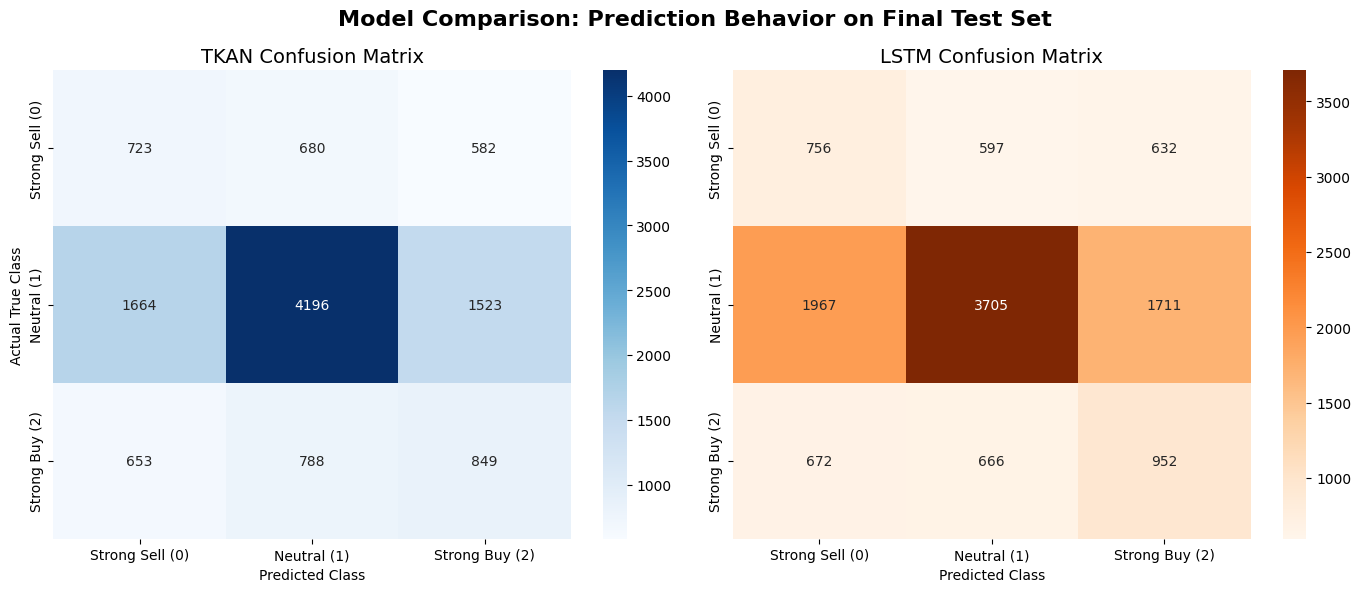

In [11]:
from sklearn.metrics import confusion_matrix
from src.train import get_model_predictions

# Run inference on the holdout set
targets, tkan_preds = get_model_predictions(trained_tkan, clean_test_loader, device)
_, lstm_preds = get_model_predictions(trained_lstm, clean_test_loader, device)

# Confusion matrices
cm_tkan = confusion_matrix(targets, tkan_preds)
cm_lstm = confusion_matrix(targets, lstm_preds)
class_names = ['Strong Sell (0)', 'Neutral (1)', 'Strong Buy (2)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison: Prediction Behavior on Final Test Set',
             fontsize=16, fontweight='bold')

sns.heatmap(cm_tkan, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('TKAN Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual True Class')
axes[0].set_xlabel('Predicted Class')

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('LSTM Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted Class')

plt.tight_layout()
plt.savefig('AAPL Model Comparison: Prediction Behavior on Final Test Set')
plt.show()

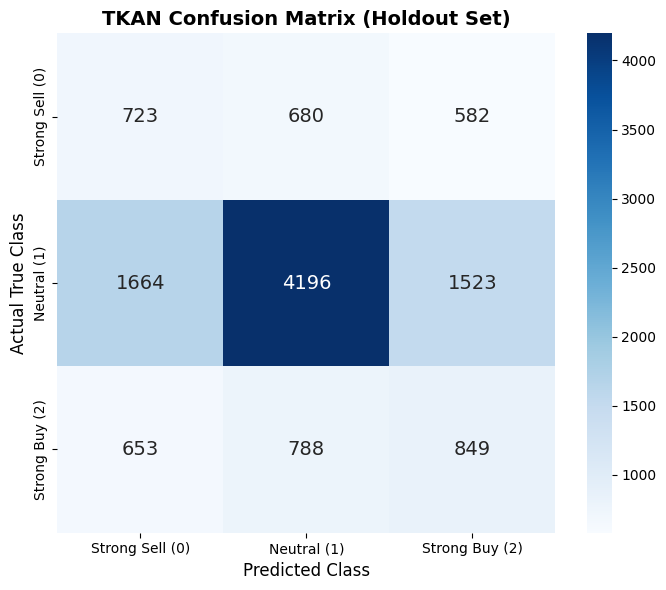

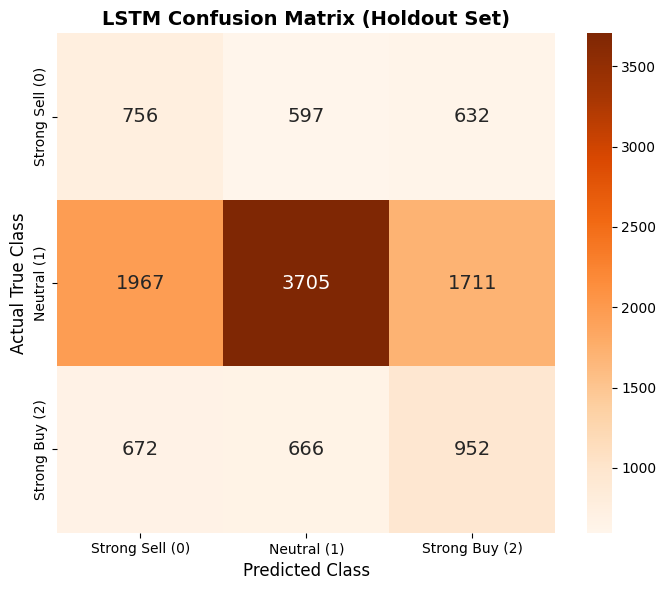

In [12]:
from sklearn.metrics import confusion_matrix
from src.train import get_model_predictions

# Run inference on the holdout set
targets, tkan_preds = get_model_predictions(trained_tkan, clean_test_loader, device)
_, lstm_preds = get_model_predictions(trained_lstm, clean_test_loader, device)

cm_tkan = confusion_matrix(targets, tkan_preds)
cm_lstm = confusion_matrix(targets, lstm_preds)
class_names = ['Strong Sell (0)', 'Neutral (1)', 'Strong Buy (2)']

os.makedirs('figures', exist_ok=True)

# --- TKAN confusion matrix (standalone figure) ---
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_tkan, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            cbar=True, annot_kws={'size': 14})
ax.set_title('TKAN Confusion Matrix (Holdout Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual True Class', fontsize=12)
ax.set_xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig('figures/cm_tkan.pdf', dpi=200, bbox_inches='tight')
plt.show()

# --- LSTM confusion matrix (standalone figure) ---
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            cbar=True, annot_kws={'size': 14})
ax.set_title('LSTM Confusion Matrix (Holdout Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual True Class', fontsize=12)
ax.set_xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig('figures/cm_lstm.pdf', dpi=200, bbox_inches='tight')
plt.show()

## 9. Results Visualization

We compare TKAN and LSTM across several dimensions:
- **Per-fold F1 bar chart** — which model wins on each forward day.
- **Learning curves** — convergence behavior during training.
- **KAN activation functions** — the learned B-spline shapes in the classifier head.
- **Stability line plot** — consistency of F1 across folds.
- **Aggregate bar chart** — overall mean F1 and accuracy with error bars.

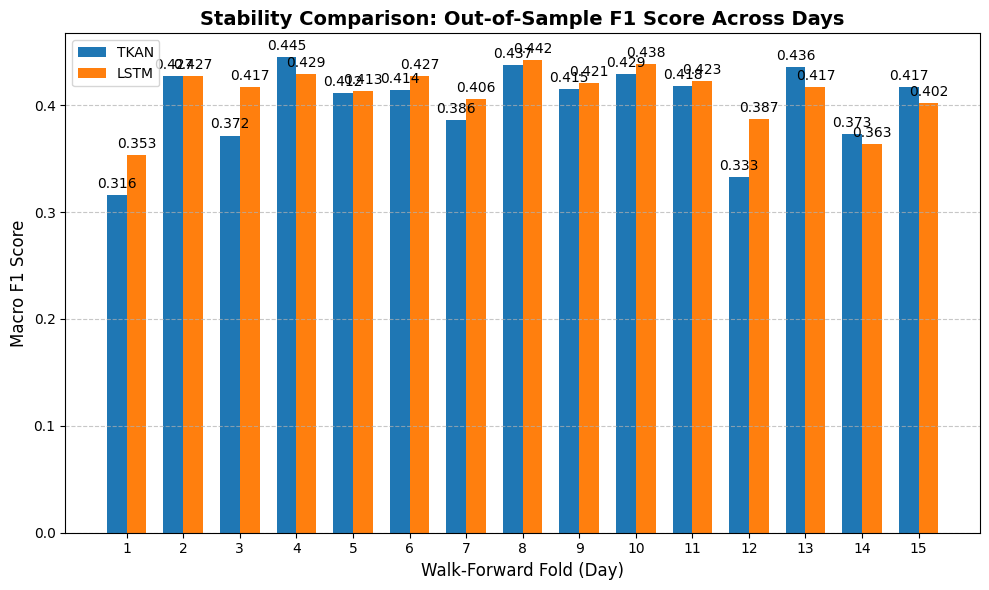

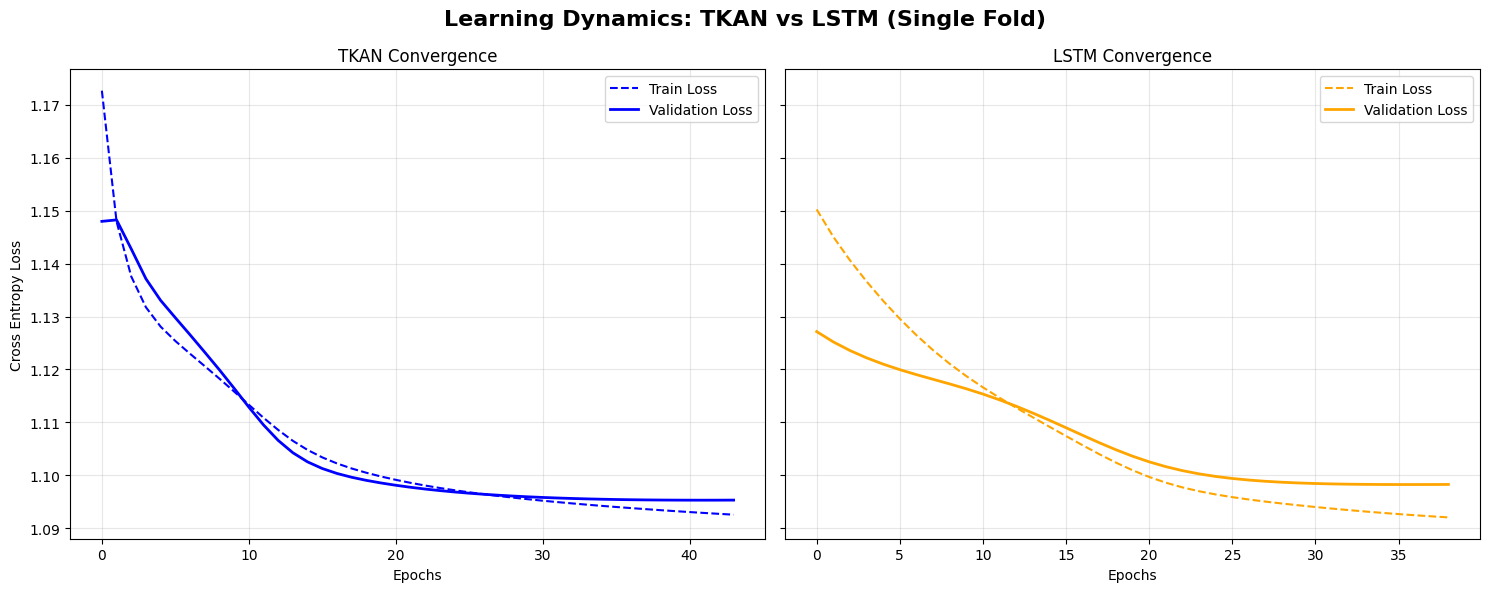

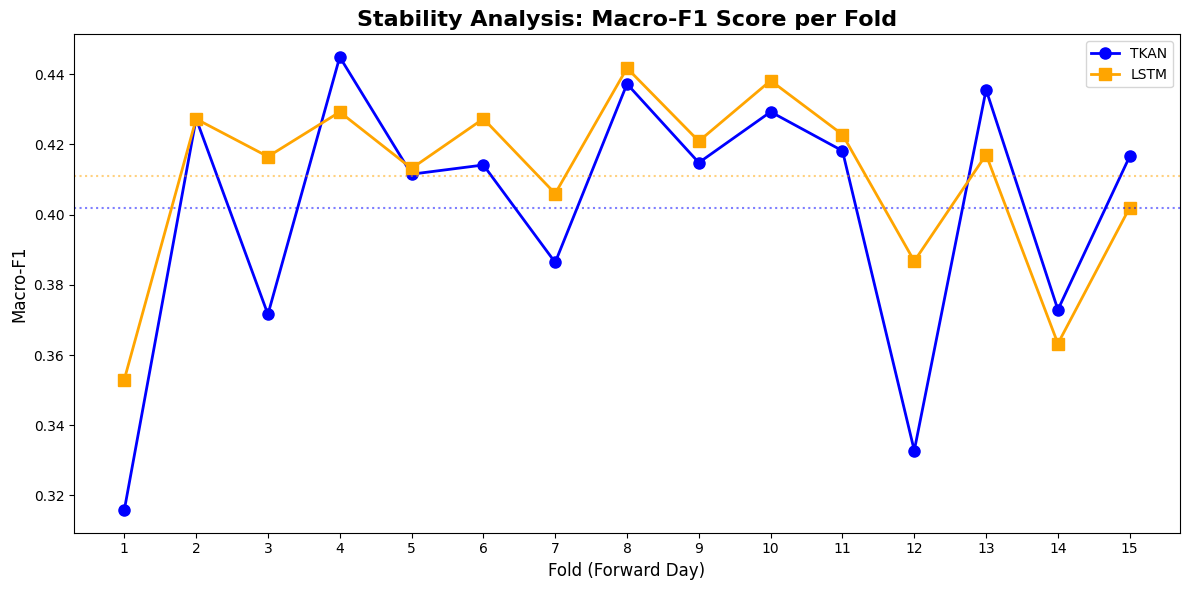

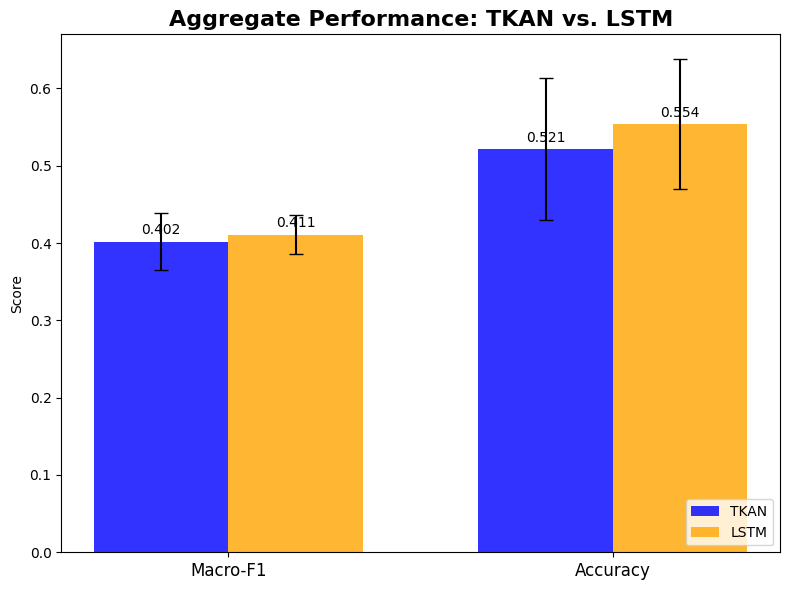

In [19]:
from src.visualizations import (
    plot_fold_comparison, plot_learning_curves,
    visualize_bspline_kan, plot_fold_stability, plot_aggregate_metrics
)

# 9.1 Per-fold F1 comparison
plot_fold_comparison(tkan_f1_scores, lstm_f1_scores,
                     save_path='AAPL Out-of-Sample F1 Score Across Days')

# 9.2 Learning curves (last fold)
plot_learning_curves(tkan_history_dict, lstm_history_dict)

# 9.3 Fold stability line plot
plot_fold_stability(tkan_f1_scores, lstm_f1_scores, metric_name="Macro-F1")

# 9.4 Aggregate metrics with error bars
plot_aggregate_metrics(tkan_f1_scores, lstm_f1_scores,
                       tkan_acc_scores, lstm_acc_scores,
                       save_path='AAPL Aggregate Performance- TKAN vs LSTM')

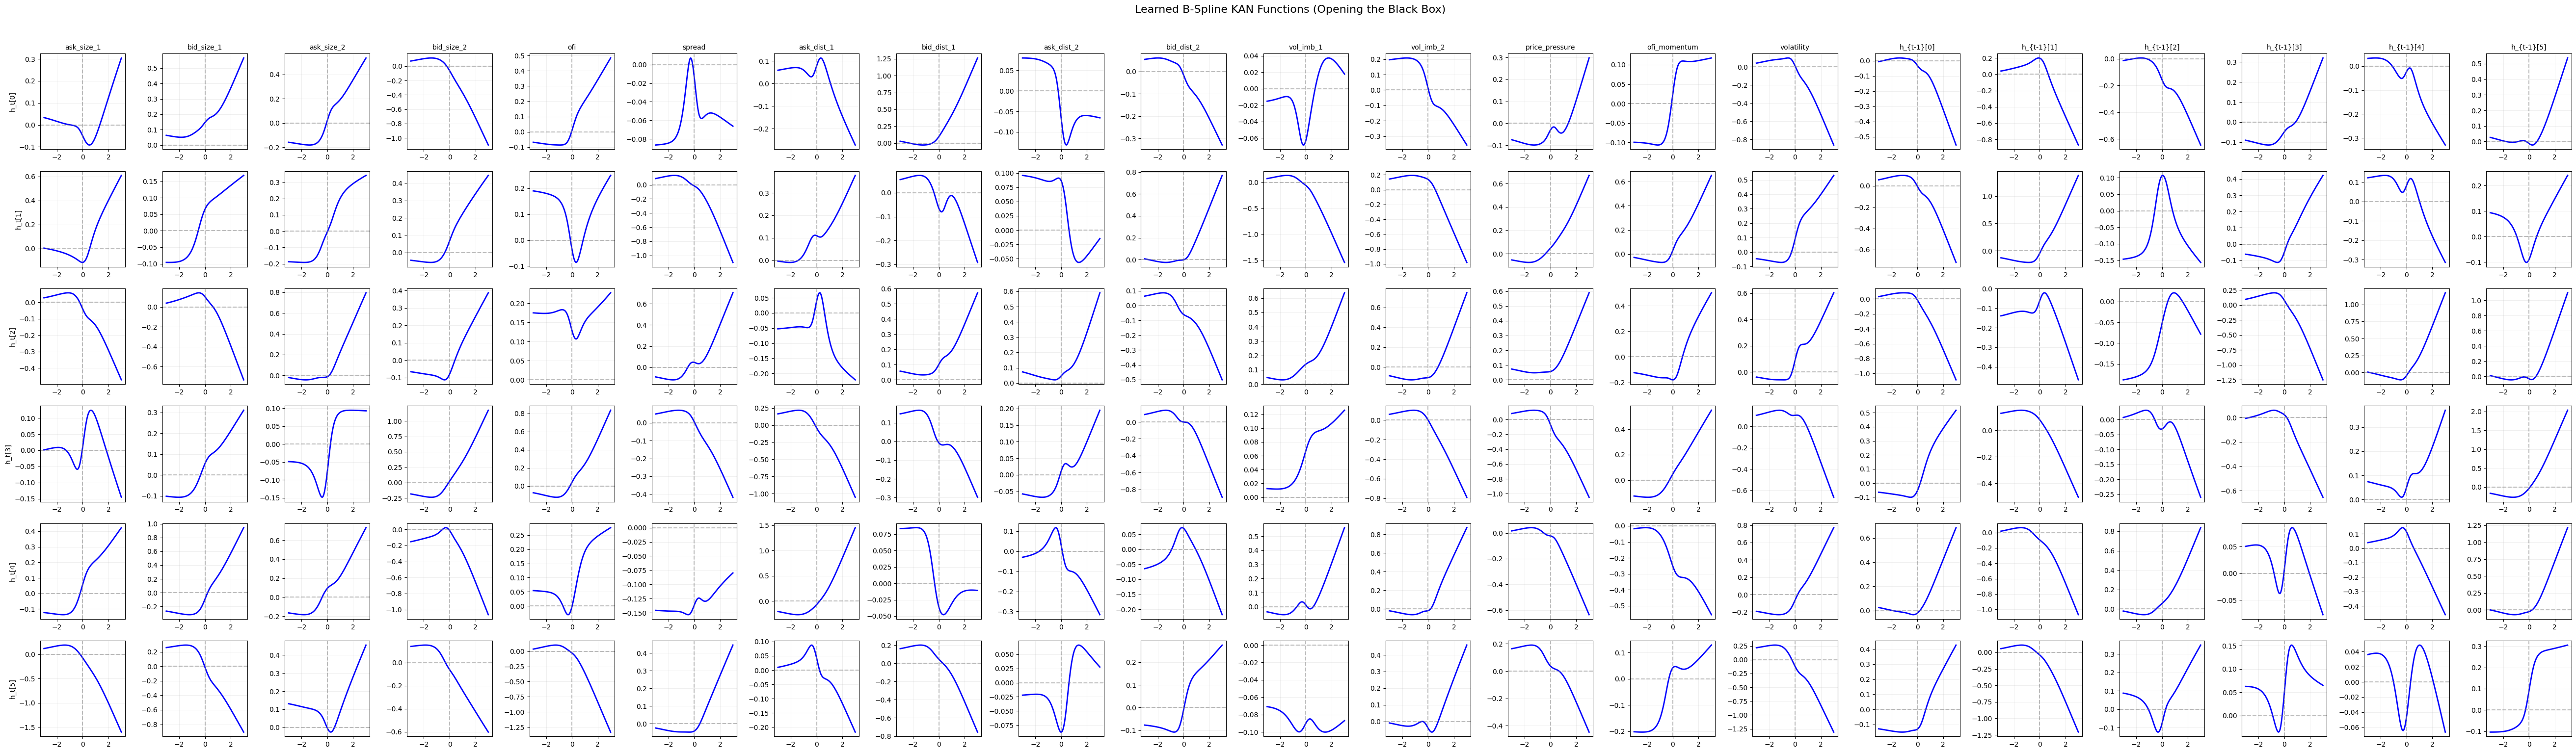

In [20]:
# 9.5 Learned KAN activation functions in the classifier head
cell_layer = trained_tkan.cells[0].kan_layer

in_dim = cell_layer.in_features      # input_size + hidden_size
hid = trained_tkan.hidden_size
feature_input_size = in_dim - hid    # = input_size (15 in your case)

# Column labels: first the 15 raw features, then the hidden-state dims
input_names = feature_cols + [f"h_{{t-1}}[{i}]" for i in range(hid)]
# Row labels: one per output hidden dim
output_names = [f"h_t[{i}]" for i in range(hid)]

visualize_bspline_kan(
    kan_layer=cell_layer,
    input_names=input_names,
    output_names=output_names,
    x_range=(-3.0, 3.0),
)

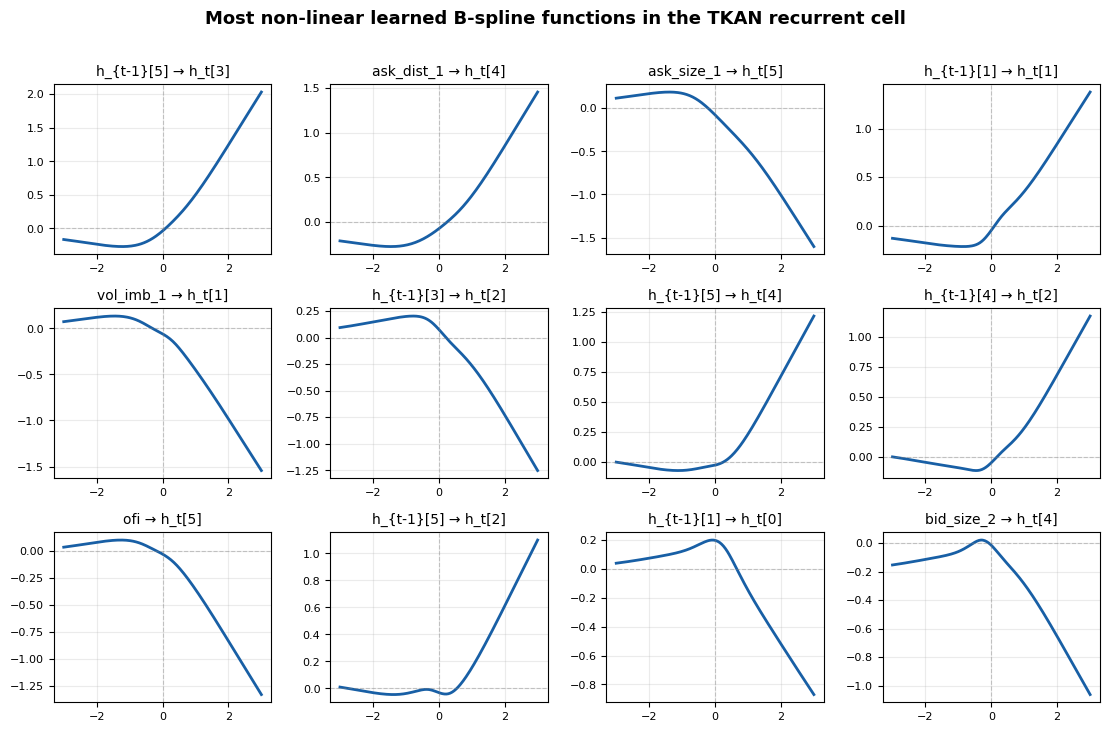

In [21]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def plot_top_kan_functions(kan_layer, input_names, output_names,
                           n_top=12, x_range=(-3.0, 3.0), num_points=200,
                           save_path=None):
    """
    Selects and plots the N most non-linear learned B-spline functions
    from a KANLinear layer. Non-linearity is measured as the std of the
    function values across the input range.
    """
    kan_layer.eval()
    device = kan_layer.spline_weight.device
    in_features  = kan_layer.in_features
    out_features = kan_layer.out_features

    x = torch.linspace(x_range[0], x_range[1], num_points, device=device)
    X_batch = x.unsqueeze(1).expand(-1, in_features)

    with torch.no_grad():
        x_clamped = torch.tanh(X_batch)
        bases = kan_layer.b_splines(x_clamped)
        base_acts = F.silu(X_batch)

    # Compute the full (out, in) grid of learned functions and rank by non-linearity
    all_curves = np.zeros((out_features, in_features, num_points))
    scores = np.zeros((out_features, in_features))
    for o in range(out_features):
        for i in range(in_features):
            spline_contrib = torch.matmul(bases[:, i, :], kan_layer.spline_weight[o, i, :])
            base_contrib   = base_acts[:, i] * kan_layer.base_weight[o, i]
            y = (spline_contrib + base_contrib).detach().cpu().numpy()
            all_curves[o, i] = y
            # Score = std of the curve (captures how much the function varies).
            # Detrend first so a purely linear ramp doesn't score highly.
            slope = np.polyfit(x.cpu().numpy(), y, 1)[0]
            residual = y - slope * x.cpu().numpy()
            scores[o, i] = residual.std()

    # Pick the top-N edges by non-linearity score
    flat_idx = np.argsort(scores.ravel())[::-1][:n_top]
    picks = [(idx // in_features, idx % in_features) for idx in flat_idx]

    # Plot in a 3x4 grid (for n_top=12) — adjust rows/cols if you change n_top
    n_cols = 4
    n_rows = int(np.ceil(n_top / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.8, n_rows * 2.4))
    axes = np.array(axes).reshape(n_rows, n_cols)

    x_np = x.cpu().numpy()
    for k, (o, i) in enumerate(picks):
        ax = axes[k // n_cols, k % n_cols]
        ax.plot(x_np, all_curves[o, i], color='#185FA5', linewidth=2)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
        ax.grid(True, alpha=0.25)
        title = f"{input_names[i]} → {output_names[o]}"
        ax.set_title(title, fontsize=10)
        ax.tick_params(labelsize=8)

    # Hide any leftover empty panels
    for k in range(n_top, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].axis('off')

    fig.suptitle(
        "Most non-linear learned B-spline functions in the TKAN recurrent cell",
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# --- Call it ---
cell_layer = trained_tkan.cells[0].kan_layer
hid = trained_tkan.hidden_size
input_names  = feature_cols + [f"h_{{t-1}}[{i}]" for i in range(hid)]
output_names = [f"h_t[{i}]" for i in range(hid)]

plot_top_kan_functions(
    kan_layer=cell_layer,
    input_names=input_names,
    output_names=output_names,
    n_top=12,
    save_path='figures/kan_functions_top12.png',
)

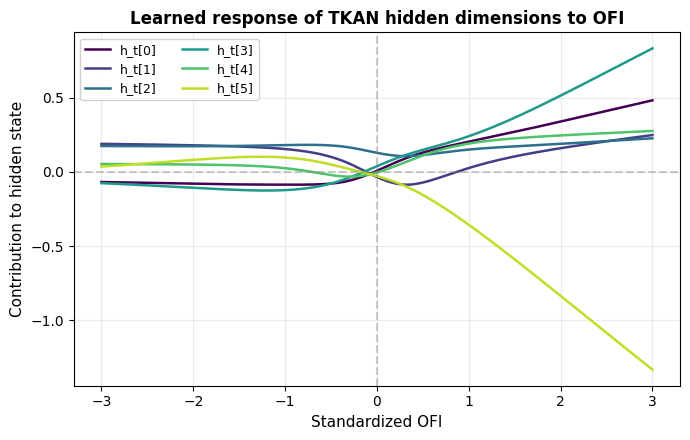

In [22]:
def plot_single_feature_response(kan_layer, feature_idx, feature_name,
                                 hidden_size, x_range=(-3.0, 3.0),
                                 num_points=200, save_path=None):
    """
    Plots how every output hidden dimension responds to a single input feature.
    One panel, one curve per output dimension — clean and compact.
    """
    kan_layer.eval()
    device = kan_layer.spline_weight.device

    x = torch.linspace(x_range[0], x_range[1], num_points, device=device)
    X_batch = x.unsqueeze(1).expand(-1, kan_layer.in_features)

    with torch.no_grad():
        x_clamped = torch.tanh(X_batch)
        bases = kan_layer.b_splines(x_clamped)
        base_acts = F.silu(X_batch)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, hidden_size))
    x_np = x.cpu().numpy()

    for o in range(hidden_size):
        spline_contrib = torch.matmul(bases[:, feature_idx, :],
                                      kan_layer.spline_weight[o, feature_idx, :])
        base_contrib = base_acts[:, feature_idx] * kan_layer.base_weight[o, feature_idx]
        y = (spline_contrib + base_contrib).detach().cpu().numpy()
        ax.plot(x_np, y, color=colors[o], linewidth=1.8, label=f"h_t[{o}]")

    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.4)
    ax.set_xlabel(f"Standardized {feature_name}", fontsize=11)
    ax.set_ylabel("Contribution to hidden state", fontsize=11)
    ax.set_title(f"Learned response of TKAN hidden dimensions to {feature_name}",
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# --- Call it for OFI ---
ofi_idx = feature_cols.index('ofi')
plot_single_feature_response(
    kan_layer=trained_tkan.cells[0].kan_layer,
    feature_idx=ofi_idx,
    feature_name='OFI',
    hidden_size=trained_tkan.hidden_size,
    save_path='figures/kan_ofi_response.png',
)

## 10. Logistic Regression Baseline & Statistical Tests

A linear baseline is essential for judging whether the deep models capture genuine non-linear patterns.  
We run the same Day-Forward protocol with a **Logistic Regression** (balanced class weights),
then apply a **paired Wilcoxon signed-rank test** on per-fold Macro-F1 scores to check statistical significance.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from scipy.stats import wilcoxon
from src.train import assign_classes

# --- Day-Forward Validation for Logistic Regression ---
df_lr = df_train_val.copy()
df_lr['date_only'] = df_lr.index.date
unique_dates_lr = sorted(df_lr['date_only'].unique())

lr_f1_scores, lr_acc_scores = [], []

print("=" * 60)
print("Starting Day-Forward Validation (LogisticRegression)")

for fold, i in enumerate(range(1, len(unique_dates_lr)), start=1):
    train_dates = unique_dates_lr[:i]
    test_date = unique_dates_lr[i]

    train_df = df_lr[df_lr['date_only'].isin(train_dates)].copy()
    test_df  = df_lr[df_lr['date_only'] == test_date].copy()

    # Quantile thresholds from training data only
    q_low = train_df['next_ofi'].quantile(0.2)
    q_high = train_df['next_ofi'].quantile(0.8)
    train_df = assign_classes(train_df, q_low, q_high)
    test_df  = assign_classes(test_df,  q_low, q_high)

    X_tr, y_tr = train_df[feature_cols].values, train_df['target'].values
    X_te, y_te = test_df[feature_cols].values,  test_df['target'].values

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    # balanced class weights approximate the [3,1,3] manual weighting
    clf = LogisticRegression(max_iter=1000, class_weight='balanced',
                              solver='lbfgs', C=1.0) 
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)

    f1  = f1_score(y_te, preds, average='macro')
    acc = accuracy_score(y_te, preds)
    lr_f1_scores.append(f1)
    lr_acc_scores.append(acc)
    print(f"Fold {fold:>2} | Test: {test_date} | F1: {f1:.4f} | Acc: {acc:.4f}")

print("\n" + "=" * 60)
print(f"Macro-F1: {np.mean(lr_f1_scores):.4f} (+/- {np.std(lr_f1_scores):.4f})")
print(f"Accuracy: {np.mean(lr_acc_scores):.4f} (+/- {np.std(lr_acc_scores):.4f})")
print("=" * 60)

Starting Day-Forward Validation (LogisticRegression)
Fold  1 | Test: 2025-09-23 | F1: 0.3999 | Acc: 0.7043
Fold  2 | Test: 2025-09-24 | F1: 0.4447 | Acc: 0.6987
Fold  3 | Test: 2025-09-25 | F1: 0.4352 | Acc: 0.6030
Fold  4 | Test: 2025-09-26 | F1: 0.4224 | Acc: 0.6329
Fold  5 | Test: 2025-09-29 | F1: 0.4136 | Acc: 0.5893
Fold  6 | Test: 2025-09-30 | F1: 0.4371 | Acc: 0.6231
Fold  7 | Test: 2025-10-01 | F1: 0.4112 | Acc: 0.5201
Fold  8 | Test: 2025-10-02 | F1: 0.4338 | Acc: 0.6064
Fold  9 | Test: 2025-10-03 | F1: 0.4276 | Acc: 0.5348
Fold 10 | Test: 2025-10-06 | F1: 0.4371 | Acc: 0.5850
Fold 11 | Test: 2025-10-07 | F1: 0.4249 | Acc: 0.7158
Fold 12 | Test: 2025-10-08 | F1: 0.3878 | Acc: 0.4453
Fold 13 | Test: 2025-10-09 | F1: 0.4197 | Acc: 0.5846
Fold 14 | Test: 2025-10-10 | F1: 0.3899 | Acc: 0.4380
Fold 15 | Test: 2025-10-13 | F1: 0.4023 | Acc: 0.5658

Macro-F1: 0.4191 (+/- 0.0173)
Accuracy: 0.5898 (+/- 0.0803)


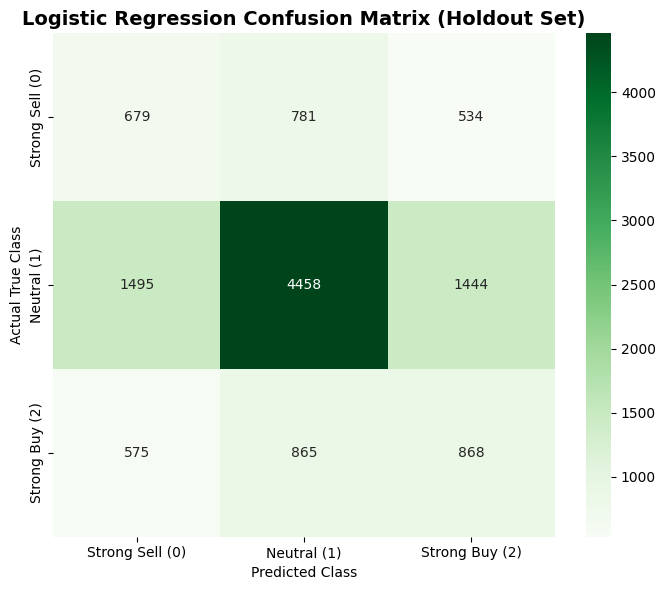

In [24]:
# --- Logistic Regression Confusion Matrix on the Holdout Set ---
# Train a final LR on the full training period, evaluate on the same holdout as the deep models
df_train_val_lr = assign_classes(df_train_val.copy(), q_lower, q_upper)

X_train_lr = scaler.fit_transform(df_train_val_lr[feature_cols].values)
X_test_lr  = scaler.transform(df_test_clean[feature_cols].values)
y_train_lr = df_train_val_lr['target'].values
y_test_lr  = df_test_clean['target'].values

final_lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                               solver='lbfgs', C=1.0) 
final_lr.fit(X_train_lr, y_train_lr)
lr_holdout_preds = final_lr.predict(X_test_lr)

cm_lr = confusion_matrix(y_test_lr, lr_holdout_preds)
class_names_lr = ['Strong Sell (0)', 'Neutral (1)', 'Strong Buy (2)']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names_lr, yticklabels=class_names_lr, ax=ax)
ax.set_title('Logistic Regression Confusion Matrix (Holdout Set)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Actual True Class')
ax.set_xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('figures/cm_logreg.png', dpi=200, bbox_inches='tight')
plt.show()

In [16]:
# --- Wilcoxon signed-rank tests ---
print("Paired Wilcoxon signed-rank tests on per-fold Macro-F1:")
for name_a, scores_a, name_b, scores_b in [
    ("TKAN", tkan_f1_scores, "LogReg", lr_f1_scores),
    ("LSTM", lstm_f1_scores, "LogReg", lr_f1_scores),
    ("TKAN", tkan_f1_scores, "LSTM",   lstm_f1_scores),
]:
    stat, p = wilcoxon(scores_a, scores_b)
    diff = np.mean(scores_a) - np.mean(scores_b)
    print(f"  {name_a} vs {name_b}: mean diff = {diff:+.4f}, W = {stat:.2f}, p = {p:.4f}")

# --- Summary table ---
summary = pd.DataFrame({
    'Model':    ['LogisticRegression', 'LSTM', 'TKAN'],
    'Macro-F1': [np.mean(lr_f1_scores), np.mean(lstm_f1_scores), np.mean(tkan_f1_scores)],
    'F1 std':   [np.std(lr_f1_scores),  np.std(lstm_f1_scores),  np.std(tkan_f1_scores)],
    'Accuracy': [np.mean(lr_acc_scores), np.mean(lstm_acc_scores), np.mean(tkan_acc_scores)],
    'Acc std':  [np.std(lr_acc_scores),  np.std(lstm_acc_scores),  np.std(tkan_acc_scores)],
})
print("\nFinal comparison table:")
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Paired Wilcoxon signed-rank tests on per-fold Macro-F1:
  TKAN vs LogReg: mean diff = -0.0172, W = 25.00, p = 0.0479
  LSTM vs LogReg: mean diff = -0.0081, W = 23.00, p = 0.0353
  TKAN vs LSTM: mean diff = -0.0091, W = 38.00, p = 0.2293

Final comparison table:
             Model  Macro-F1  F1 std  Accuracy  Acc std
LogisticRegression    0.4191  0.0173    0.5898   0.0803
              LSTM    0.4110  0.0248    0.5542   0.0839
              TKAN    0.4019  0.0372    0.5214   0.0919
